In [1]:
from qiskit import __version__
print(__version__)

2.4.1


# Importing Packages

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, state_fidelity, Pauli, DensityMatrix, partial_trace
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_aer.library import SaveDensityMatrix, SaveStatevector, SetDensityMatrix
from qiskit import transpile 
import numpy as np
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.circuit.library import HGate, UnitaryGate, IGate
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter
from matplotlib.gridspec import GridSpec
from scipy.optimize import curve_fit

# Graphing Settings

In [3]:
mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 8,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.2,
    'figure.dpi': 150,
})

# Importing Data

In [7]:
data1 = np.load("scaling.npz")
data2 = np.load("threshold.npz")

rounds_arr = data1["rounds_arr"]
output_error_rate_arr = data1["output_error_rate_arr"]
lambda_ = data1["lambda_"]
input_error_rate = data2["input_error_rate"]
output_error_rate = data2["output_error_rate"]
intersection = data2["intersection"]

# Plots

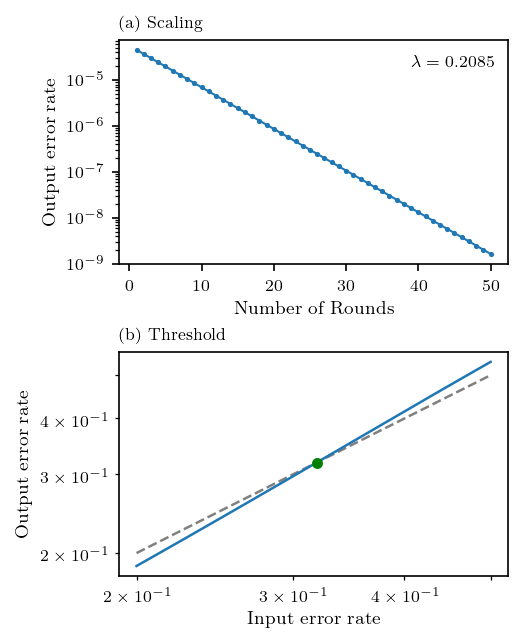

In [12]:
column_width = 3.4

fig, axes = plt.subplots(
    2, 1,
    figsize=(column_width, 4.2),
    sharex=False,
    sharey=False
)

# --- Plot 1: scaling ---
ax = axes[0]

ax.plot(
    rounds_arr,
    output_error_rate_arr,
    'o-',
    markersize=2.5,
    linewidth=1.0,
    markeredgewidth=0.0,
    zorder=3,
    label='_nolegend_'
)

# Legend with text only
dummy = plt.Line2D([], [], linestyle='none', label=rf'$\lambda={lambda_:.4f}$')
ax.legend(
    handles=[dummy],
    frameon=False,
    loc='upper right',
    handlelength=0,
    handletextpad=0
)

ax.set_yscale("log")
ax.set_xlabel("Number of Rounds")
ax.set_ylabel("Output error rate")
ax.set_title(r"(a) Scaling", loc="left", fontsize=8)


# --- Plot 2: threshold ---
ax = axes[1]

ax.plot(
    input_error_rate,
    input_error_rate,
    color="gray",
    linestyle="--"
)

ax.plot(
    input_error_rate,
    output_error_rate
)

ax.scatter(
    intersection,
    intersection,
    color="green",
    s=18,
    zorder=5
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Input error rate")
ax.set_ylabel("Output error rate")
ax.set_title(r"(b) Threshold", loc="left", fontsize=8)

plt.tight_layout(pad=0.5)

plt.show()